# DarkNESS ALP concept of operations — the pictures

Six figures for intuition: how a geomagnetic ALP search is done from a
spacecraft, and what the DarkNESS ConOps has to get right. Every picture is
drawn from the simulated mission (`main_sequence.ipynb`, same settings); the
figure code is in `scripts/conops_figures.py` so the deck can reuse it.

Three geometry pictures come first (A, B, C): the orbit in space, the
magnetic field itself, and the fan of rays from one spot. They are
the pointing strategy before any signal. Then the six:

1. **The conversion path** — the signal is a line integral of $\mathbf B_\perp$
   along the line of sight, through the field, until the Earth or empty space.
2. **What the aperture sees** — a 20° cone, and how much $K$ changes across it.
3. **One orbit** — $K$, the particle-background proxy and the limb angle rise
   and fall together: the identifiability problem.
4. **The ground track** — where science happens in a day, the modes, the
   weak-field region.
5. **Where to point** — every fixed sky direction held for a day, for the
   continuum, the Milky Way line, and the confound.
6. **What it buys** — expected counts for the allowed benchmark, and the
   mass reach from the phase-aware integral.

In [1]:
import sys; sys.path.append("../scripts")
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from darknessalp import (orbit, pointing, kinematics, sim, frames, field,
                         geometry, source)
from darknessalp.constants import R_EQUATOR_KM
from fov_view import fov_view
import conops_figures as cf

EPOCH = "2027-05-01T00:00:00"     # UTC
ALT_KM, INC_DEG = 420.0, 51.6      # ISS-like
ELEMENTS = dict(a_km=R_EQUATOR_KM + ALT_KM, e=0.0, inc_deg=INC_DEG,
                raan_deg=0.0, argp_deg=0.0, nu_deg=0.0)   # CCSDS OPM, GCRF
GRAVITY = "j2"
CADENCE_S, DURATION_S = 60.0, 86400.0
LMAX = 13
SLEW_DEG_S = 1.5                   # ASSUME
SCIENCE = pointing.mode("gc", roll="anti_earth")
SUNLIT = pointing.mode("anti_sun", roll="anti_earth")
RULES = [("umbra", SCIENCE), ("always", SUNLIT)]

## The mission, simulated

The main sequence in one cell: orbit, schedule, steering, state table.

In [2]:
t = np.arange(0.0, DURATION_S, CADENCE_S)
time = frames.times(EPOCH, t)
r0, v0 = orbit.elements_to_state(**ELEMENTS)
r, v = orbit.propagate(r0, v0, t, gravity=GRAVITY)
mode_index, modes = pointing.select(RULES, pointing.conditions(time, r))
desired = pointing.attitudes(modes, mode_index, time, r, v)
attitude, _, slewing = kinematics.steer(desired, t, SLEW_DEG_S, mode_index=mode_index)
n = kinematics.boresight(attitude)
table = sim.state_table(EPOCH, t, r, n, lmax=LMAX)
coeffs = field.load_igrf(float(np.mean(frames.decimal_year(time))))
sci = cf.science_mask(table, mode_index) & ~slewing
k0 = int(np.flatnonzero(sci)[np.argmax(table["k_fov_t2m2"][sci])])   # strongest science sample
print(f"{len(t)} samples; science exposure {sci.sum() * CADENCE_S / 3600:.1f} h; "
      f"strongest science sample at {t[k0] / 3600:.2f} h, K = {table['k_fov_t2m2'][k0]:.0f} T² m²")

1440 samples; science exposure 8.5 h; strongest science sample at 16.20 h, K = 56991 T² m²


## The geometry of pointing

The schedule is two rules: in umbra, boresight on the Galactic
Centre with the radiator away from the Earth; otherwise boresight
anti-Sun. Everything the schedule has to respect is geometry: where
the Sun is, where the Earth is, where the target is on the sky.

### A. One orbit in space

Earth, the orbit, the Sun, the Earth's shadow, and the target
direction, which is fixed on the sky while the orbit turns under it.
The shadow is a cone narrowing by only 0.26°, so here it looks like
a cylinder; the penumbra around it takes 8 s or more to cross.
Arrows are the boresight: grey while sunlit (anti-Sun), dark blue in
umbra while the target is behind the Earth, so the boresight, still
on the target, looks into the Earth; orange during science exposure. The short red arrows are the radiator normal: once the
boresight is fixed, the one freedom left is the roll about it, and
the roll rule spends it keeping the radiator away from the Earth.

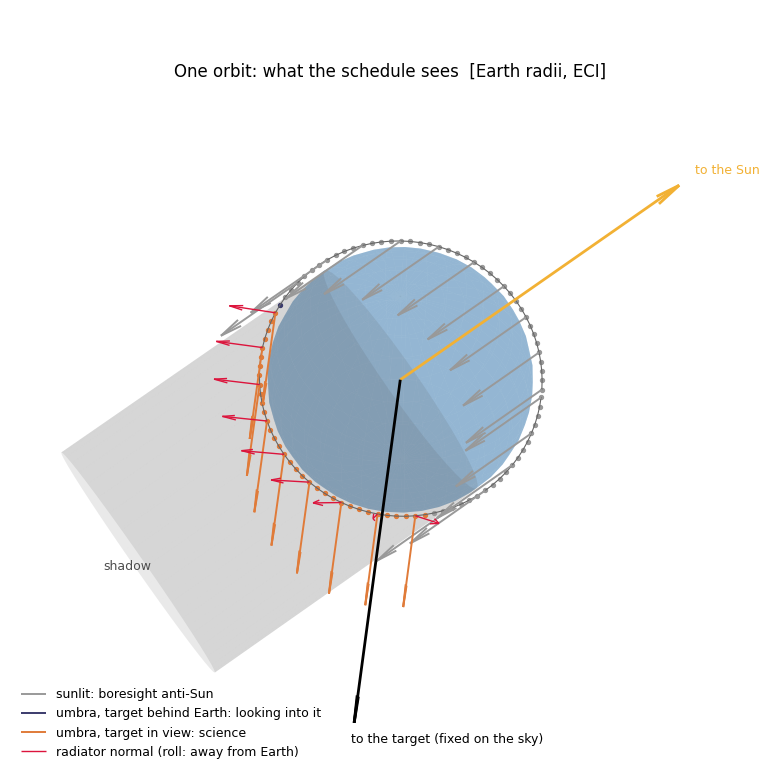

In [3]:
sun = frames.sun_vector(time)
target = pointing.sky_target(SCIENCE["primary"])
fig = cf.orbit_geometry(r, n, sun[0], target, sci, table["umbra"],
                        kinematics.radiator_normal(attitude))
plt.show()

### B. The field itself

The geomagnetic field in the one plane where its lines are drawn
true: the meridian holding both the spin axis (vertical) and the
dipole axis, tilted about 9° from it. Colour is $|B|$. To first
order the field is a dipole, so it falls as $1/r^3$: eight times
weaker at two Earth radii than at the surface. That is why the
conversion integral collects nearly all of $K$ within one or two
Earth radii of the spacecraft (figure 1). The orange arcs are the
orbit, 420 km up and reaching ±51.6° latitude. Where the
spacecraft is sets which field lines are near; where it looks
sets how much of them lie across the ray, since only
$\mathbf B_\perp$ converts.

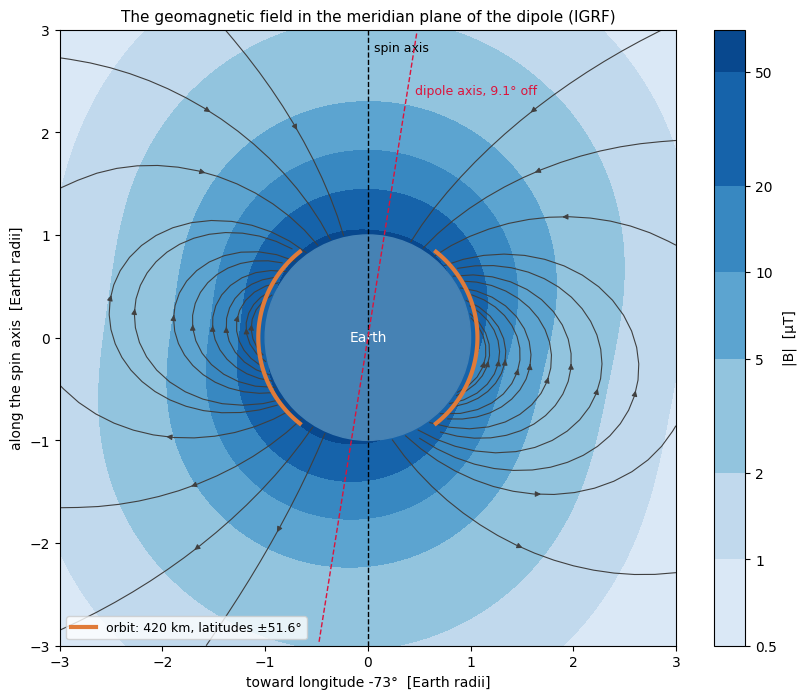

In [4]:
fig = cf.field_geometry(coeffs, ALT_KM, INC_DEG, LMAX)
plt.show()

### C. Where to look, from one spot

From the strongest science sample, a ray every 3° in the plane of
the target, coloured by $K$. $K$ is a path length through the strong
field near the Earth: rays into the Earth stop at the opaque air and
are short; rays to the zenith leave the field quickly; rays that
graze the limb travel farthest through the low field lines. The
peak is the ray that just clears the opaque air at 150 km, about 4°
above the ground limb. The
polar plot is the same fan as $|A|$ against the angle from the
zenith, Earth disk shaded, the boresight and its 20° aperture
marked. This is why $K$ peaks once per orbit, as the target sets
toward the limb (figure 3), and why the aperture average differs
from the boresight value there (figure 2).

North is up: the plot is turned so the spin axis, projected into the
plane, is vertical, and the title gives how far the plane is from
containing it. The grey lines are the field projected into this
plane, so they are true field lines only when the plane is a
magnetic meridian, as in figure B.

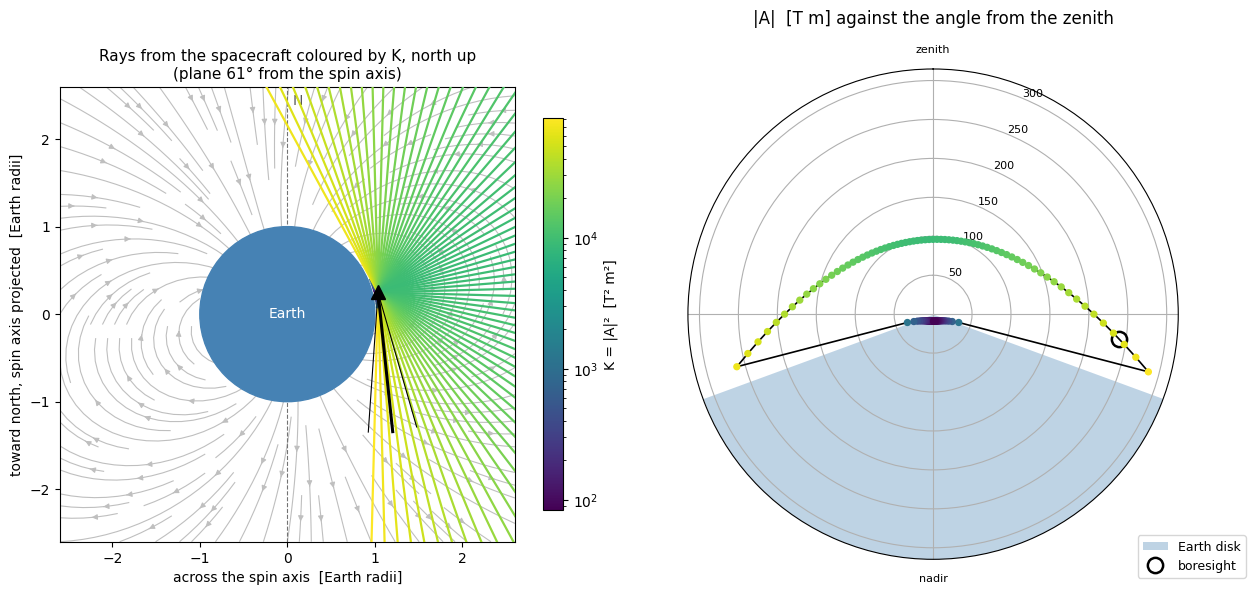

boresight 12.7 deg above the limb; Earth disk radius 69.8 deg


In [5]:
fig = cf.ray_fan(r[k0], n[k0], time[k0], coeffs, LMAX)
plt.show()
print(f"boresight {table['limb_deg'][k0]:.1f} deg above the limb; Earth disk radius "
      f"{geometry.earth_angular_radius_deg(r[k0]):.1f} deg")

## 1. The conversion path

An ALP arriving along the boresight converts to an X-ray photon in the part of
the geomagnetic field it crosses on the way to the detector. Only the field
component **perpendicular** to the ray counts, and the contributions add as an
amplitude: $A = \int \mathbf B_\perp\,e^{iqs}\,ds$, $K = |A|^2$. The ray runs
from the spacecraft outward until it leaves the field region or hits the
Earth — an occulted ray still converts along its short path. The right panel
is how $|A|$ builds up along the ray at the moment of the day when $K$ is
largest.

North is up: the plot is turned so the spin axis, projected into the
plane, is vertical, and the title gives how far the plane is from
containing it. The grey lines are the field projected into this
plane, so they are true field lines only when the plane is a
magnetic meridian, as in figure B.

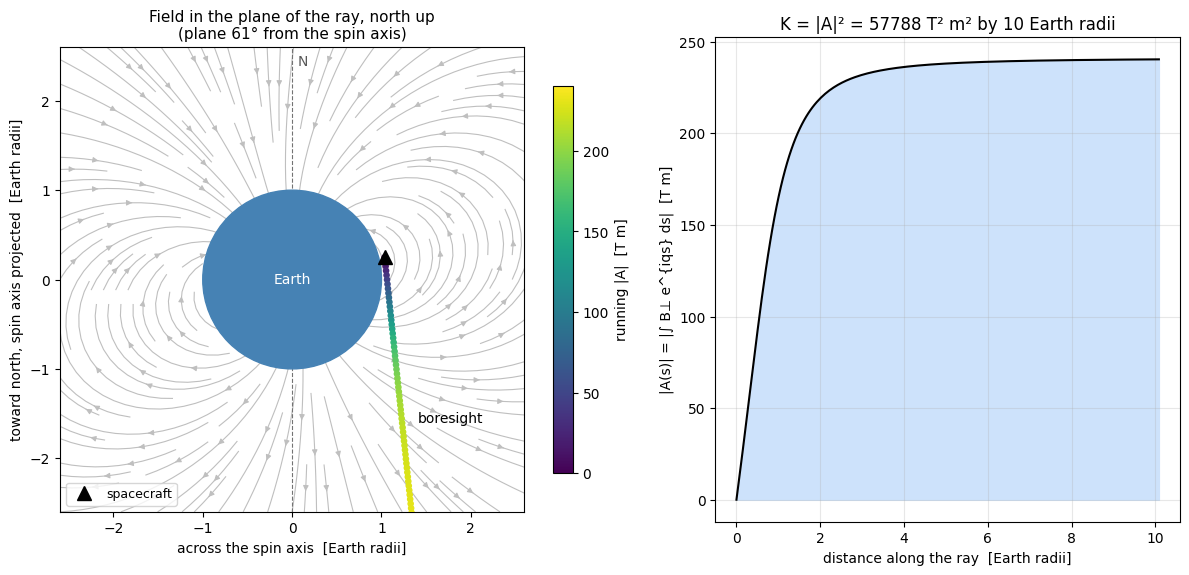

In [6]:
fig = cf.meridian_plane(r[k0], n[k0], time[k0], coeffs, LMAX)
plt.show()

## 2. What the aperture sees

The four apertures give a 20° full cone. $K$ is not constant across it — the
field geometry changes from one edge of the cone to the other, and the Earth
limb can cut through it. The state table therefore carries $K$ averaged over
the cone (`k_fov_t2m2`), not the boresight value. Same moment as figure 1.

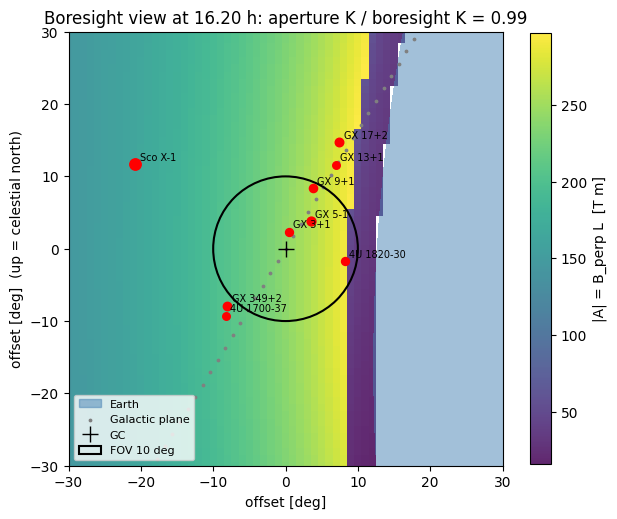

In [7]:
ax = fov_view(r[k0], time[k0], n[k0], coeffs, extent=30.0, lmax=LMAX)
ax.set_title(f"Boresight view at {t[k0] / 3600:.2f} h: aperture K / boresight K = "
             f"{table['k_fov_t2m2'][k0] / table['k_t2m2'][k0]:.2f}")
plt.show()

## 3. One orbit

Three orbits of the day. $K$ peaks once per orbit, where the boresight
grazes the limb; the particle-background proxy (cutoff rigidity) peaks at
the magnetic equator; both are set by where the spacecraft is in the field.
Science exposure (shaded) is umbra with the sky in view. Because $K$ and the
background proxy move together, a schedule has to *decorrelate* them, not
just maximise $K$.

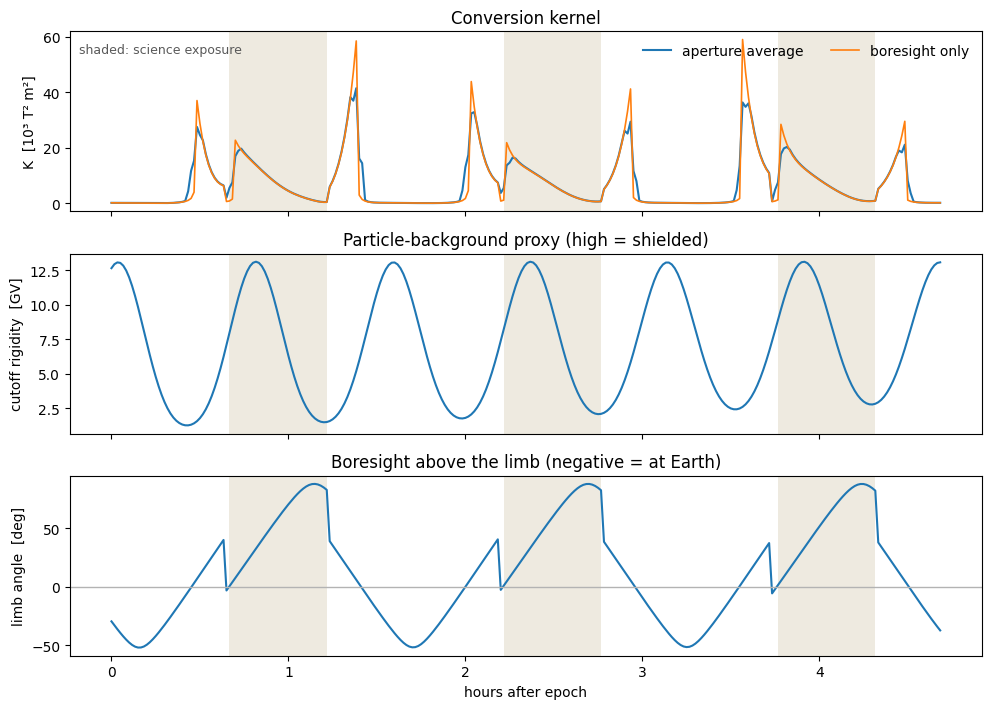

over the day's science exposure: corr(K, cutoff rigidity) = +0.77, corr(K, limb angle) = -0.81


In [8]:
fig = cf.orbit_strip(table, mode_index)
plt.show()
rho = np.corrcoef(table["k_fov_t2m2"][sci], table["cutoff_gv"][sci])[0, 1]
rho_limb = np.corrcoef(table["k_fov_t2m2"][sci], table["limb_deg"][sci])[0, 1]
print(f"over the day's science exposure: corr(K, cutoff rigidity) = {rho:+.2f}, corr(K, limb angle) = {rho_limb:+.2f}")

## 4. The ground track

Where the spacecraft is when each mode runs. Grey: sunlit, boresight
anti-Sun. Dark blue: in umbra but the Galactic Centre is behind the Earth.
Coloured: science exposure, coloured by aperture $K$. The shaded patch is
where the field is weakest at this altitude — the South Atlantic Anomaly,
where trapped particles reach the spacecraft and science normally stops
(ALP-MA-17, mask not yet applied).

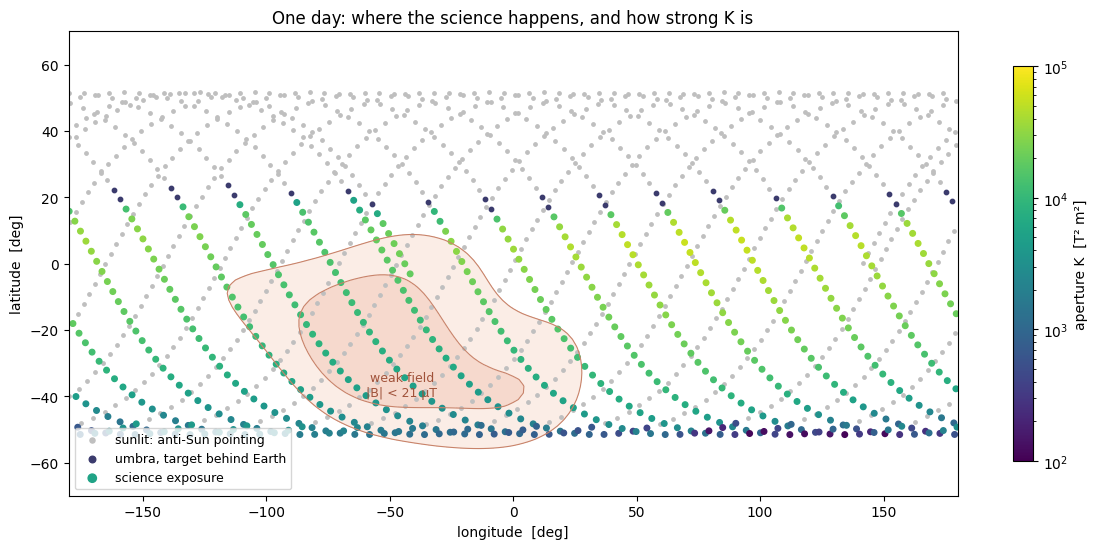

In [9]:
fig = cf.ground_track(table, coeffs, mode_index, ALT_KM)
plt.show()

## 5. Where to point

Every fixed inertial direction on the sky, each held for the whole day, at
5-minute cadence. Left: the isotropic continuum signal, $\sum\langle K\rangle
\Delta t$, relative to Galactic Centre pointing. Middle: the Milky Way line,
which also carries the halo column, $\sum\langle D\,K\rangle\Delta t$. Right:
how strongly $K$ tracks the background proxy for that pointing. The sky
splits into a half where the signal rises with the background and a half
where it falls — the ConOps lever.

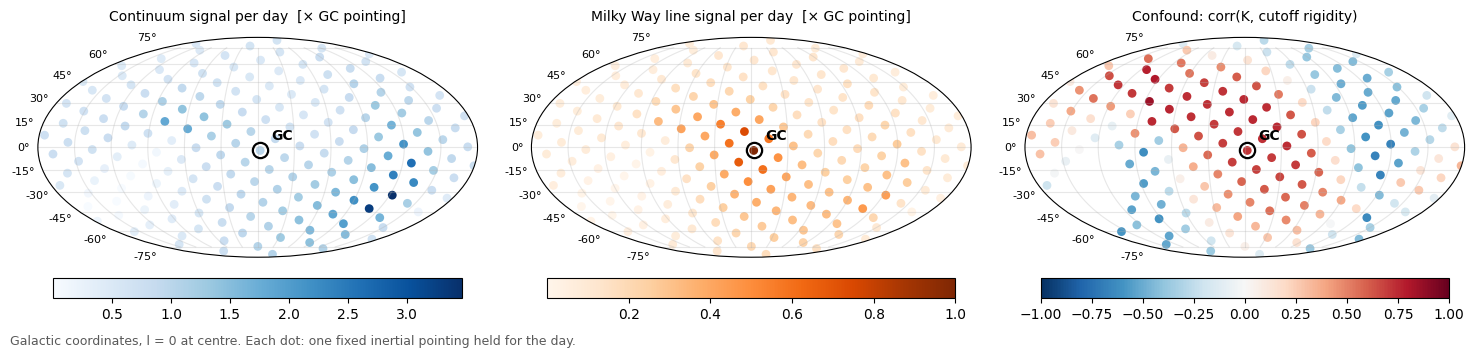

GC pointing: continuum rank 60/192, corr(K, Rc) = +0.72
best continuum direction: l = 238, b = -32: 3.5× GC, corr = -0.44, line signal 0.43× GC


In [10]:
step = int(300 / CADENCE_S)
scan = cf.sky_scan(time[::step], r[::step], coeffs, LMAX, n_dir=192)
fig, sky = cf.sky_maps(scan, table["umbra"][::step], table["cutoff_gv"][::step], 300.0)
plt.show()
gc = sky["gc"]
best = int(np.nanargmax(sky["rel_continuum"]))
rank = int(np.sum(sky["rel_continuum"] > 1.0)) + 1
print(f"GC pointing: continuum rank {rank}/{len(scan['l'])}, corr(K, Rc) = {sky['corr'][gc]:+.2f}")
print(f"best continuum direction: l = {scan['l'][best]:.0f}, b = {scan['b'][best]:.0f}: "
      f"{sky['rel_continuum'][best]:.1f}× GC, corr = {sky['corr'][best]:+.2f}, "
      f"line signal {sky['rel_line'][best]:.2f}× GC")

## 6. What it buys

The allowed-signal ceiling: the largest externally allowed benchmark
($g_{a\gamma\gamma}$ at the CAST bound, the invisible-decay rate at its
cosmological limit) folded through this schedule for the 187-day science
phase, one simulated day standing for all. Conversion uses Yamamoto's
normalisation, $P = 2.45\times10^{-21}\,(g/10^{-10}\,\mathrm{GeV^{-1}})^2\,K$.
The mass dependence comes from the phase-aware integral itself: $K$ depends
on $m_a$ only through $q = m_a^2/2E$. The line and the continuum
are Block B's $\chi\to aa$ spectra (`source.line_intensity`,
`source.continuum_intensity`) with the parent share folded into
the lifetime, $1/\tau = f\,\mathrm{Br}/\tau$ at its limit; the
continuum is integrated over the 2–6 keV band.

187 days: Milky Way line 8.3e-03 counts, continuum 5.3e-04 counts


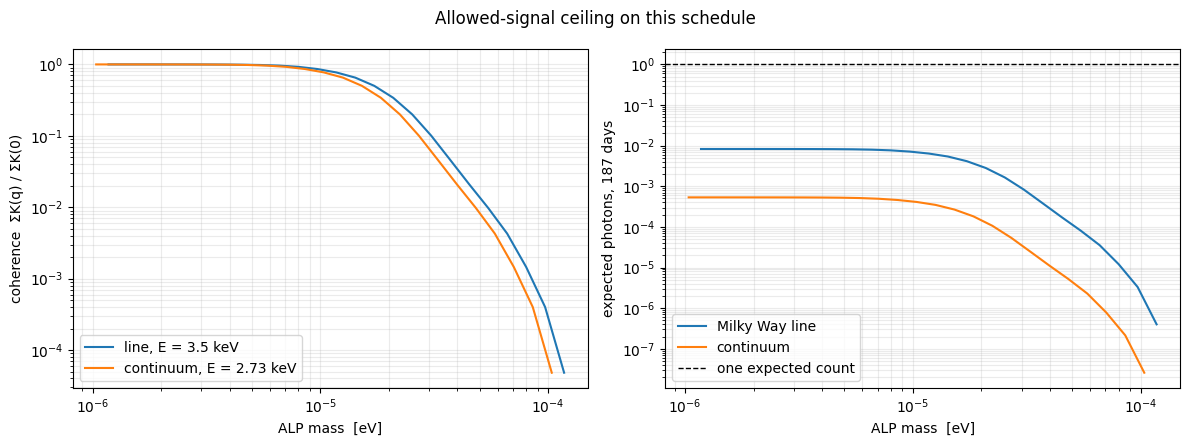

coherence halves at m = 1.7e-05 eV


In [11]:
G_GEV_INV, DECAY_RATE_GYR, PARENT_MASS_KEV = 5.8e-11, 6.3e-3, 7.0
AREA_CM2, THROUGHPUT, MISSION_DAYS = 12.0, 0.20, 187
E_LO, E_HI, HBAR_C_EV_M = 2.0, 6.0, 1.973269804e-7

scale = CADENCE_S * MISSION_DAYS
grasp = AREA_CM2 * 2 * np.pi * (1 - np.cos(np.radians(10.0)))
p_per_k = 2.45e-21 * (G_GEV_INV / 1e-10) ** 2
tau_gyr = 1 / DECAY_RATE_GYR             # share 1: the benchmark is f Br / tau
k_sum = table["k_fov_t2m2"][sci].sum() * scale
dk_sum = table["dk_fov_gevcm2_t2m2"][sci].sum() * scale
line_counts = (source.line_intensity(dk_sum, PARENT_MASS_KEV, 1.0, tau_gyr)
               * p_per_k * grasp * THROUGHPUT)
e_band = np.linspace(E_LO, E_HI, 4001)
di_de = source.continuum_intensity(e_band, PARENT_MASS_KEV, 1.0, tau_gyr)
cont_band = trapezoid(di_de, e_band)
e_mean = trapezoid(e_band * di_de, e_band) / cont_band
cont_counts = cont_band * p_per_k * k_sum * grasp * THROUGHPUT
print(f"{MISSION_DAYS} days: Milky Way line {line_counts:.1e} counts, "
      f"continuum {cont_counts:.1e} counts")

q_grid = np.geomspace(1e-9, 1e-5, 25)
coh = cf.coherence_scan(r, n, time, coeffs, np.flatnonzero(sci)[::8], q_grid,
                        LMAX)


def mass(e_kev):
    return np.sqrt(2 * e_kev * 1e3 * HBAR_C_EV_M * q_grid)


fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].loglog(mass(PARENT_MASS_KEV / 2), coh,
             label=f"line, E = {PARENT_MASS_KEV / 2:g} keV")
ax[0].loglog(mass(e_mean), coh, label=f"continuum, E = {e_mean:.2f} keV")
ax[0].set_xlabel("ALP mass  [eV]")
ax[0].set_ylabel("coherence  ΣK(q) / ΣK(0)")
ax[1].loglog(mass(PARENT_MASS_KEV / 2), line_counts * coh,
             label="Milky Way line")
ax[1].loglog(mass(e_mean), cont_counts * coh, label="continuum")
ax[1].axhline(1, color="k", ls="--", lw=1, label="one expected count")
ax[1].set_xlabel("ALP mass  [eV]")
ax[1].set_ylabel(f"expected photons, {MISSION_DAYS} days")
for a in ax:
    a.grid(True, which="both", alpha=0.25)
    a.legend()
fig.suptitle("Allowed-signal ceiling on this schedule")
fig.tight_layout()
plt.show()
m_half = np.interp(0.5, coh[::-1], mass(PARENT_MASS_KEV / 2)[::-1])
print(f"coherence halves at m = {m_half:.1e} eV")

## Reading the pictures

- The signal is geometry: a line integral through the field, set by where
  the spacecraft is and where it looks. No sky target is required for the
  continuum; the Milky Way line adds the halo column on top.
- The aperture is wide enough that $K$ must be averaged over it; the
  boresight value can be off by tens of percent near the limb.
- The particle background follows the same geometry, so the raw size of
  $K$ is not the figure of merit — how *separable* its modulation is from
  the background's is (figures 3 and 5).
- Nominal Galactic Centre pointing is average for the continuum and sits in
  the high-confound half of the sky; better directions exist for the
  continuum, and they are poor for the line. The two channels want
  different ConOps.
- Even the largest allowed benchmark is far below one count for this
  schedule; the mission question is identifiability and method, not a
  coupling limit (charter, D18).
